In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
df = pd.read_csv("../data/diamonds.csv")

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
df.shape

(53940, 11)

In [7]:
df = df.drop("Unnamed: 0", axis=1)

In [8]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [10]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [14]:
len(df[df["x"] == 0]), len(df[df["y"] == 0]), len(df[df["z"] == 0])

(8, 7, 20)

In [17]:
df[df["x"] == 0].index

Index([11182, 11963, 15951, 24520, 26243, 27429, 49556, 49557], dtype='int64')

In [19]:
df = df.drop(df[df["x"] == 0].index, axis=0)
df = df.drop(df[df["y"] == 0].index, axis=0)
df = df.drop(df[df["z"] == 0].index, axis=0)

In [20]:
df.shape

(53920, 10)

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53920.0,0.797698,0.473795,0.20,0.40,0.70,1.04,5.01
depth,53920.0,61.749514,1.432331,43.00,61.00,61.80,62.50,79.00
table,53920.0,57.456834,2.234064,43.00,56.00,57.00,59.00,95.00
price,53920.0,3930.993231,3987.280446,326.00,949.00,2401.00,5323.25,18823.00
x,53920.0,5.731627,1.119423,3.73,4.71,5.70,6.54,10.74
y,53920.0,5.734887,1.140126,3.68,4.72,5.71,6.54,58.90
z,53920.0,3.540046,0.702530,1.07,2.91,3.53,4.04,31.80


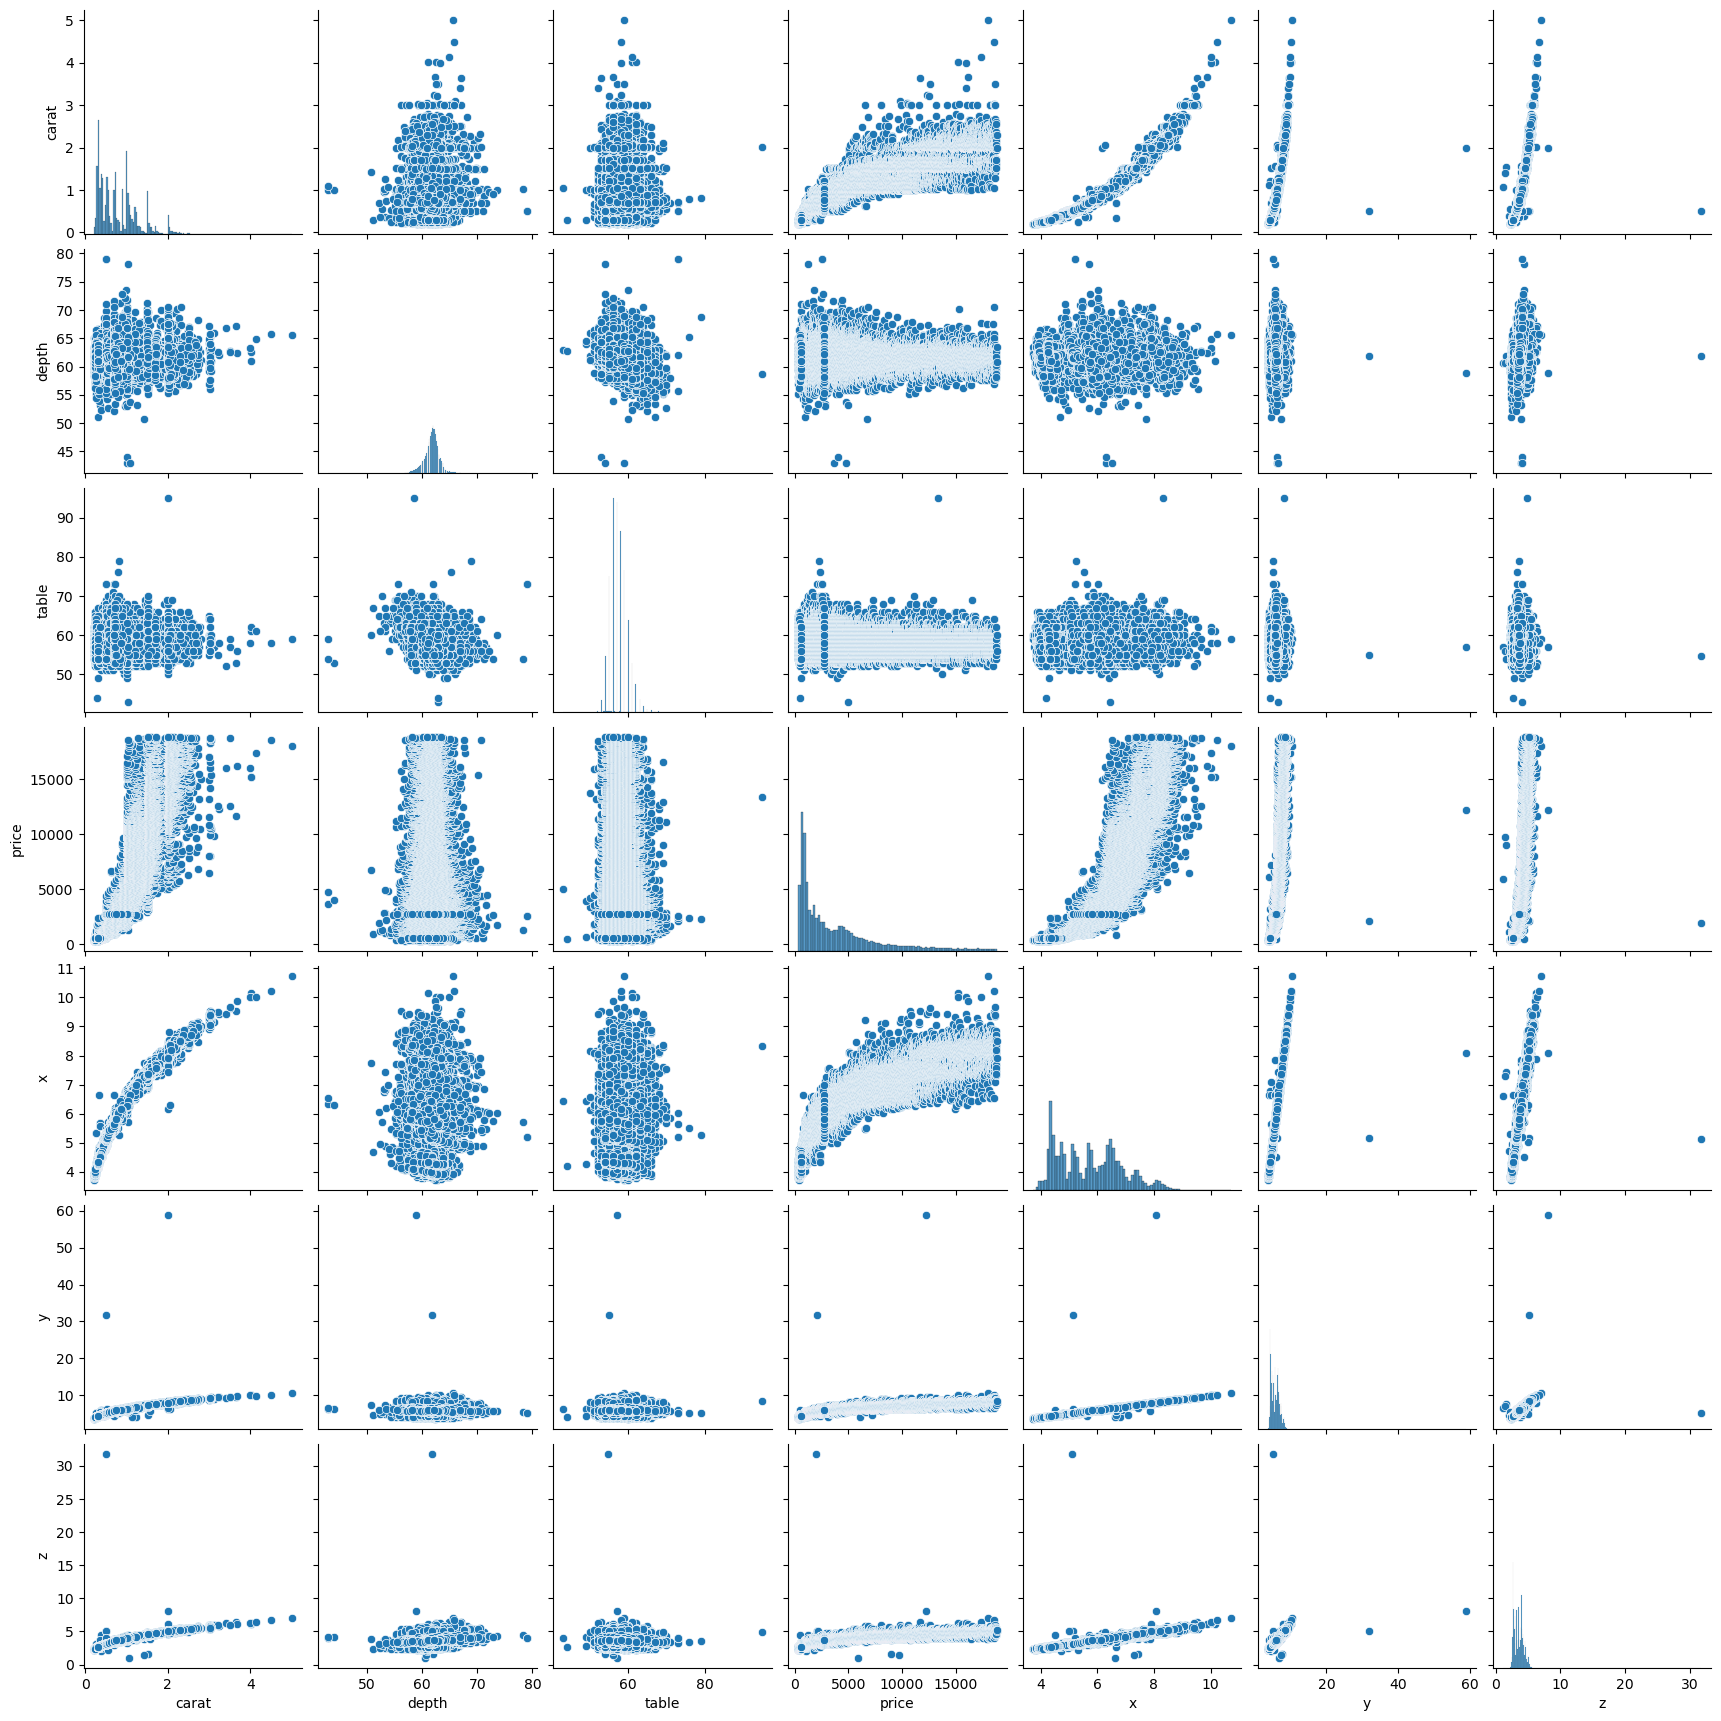

In [22]:
sns.pairplot(df)
plt.show()

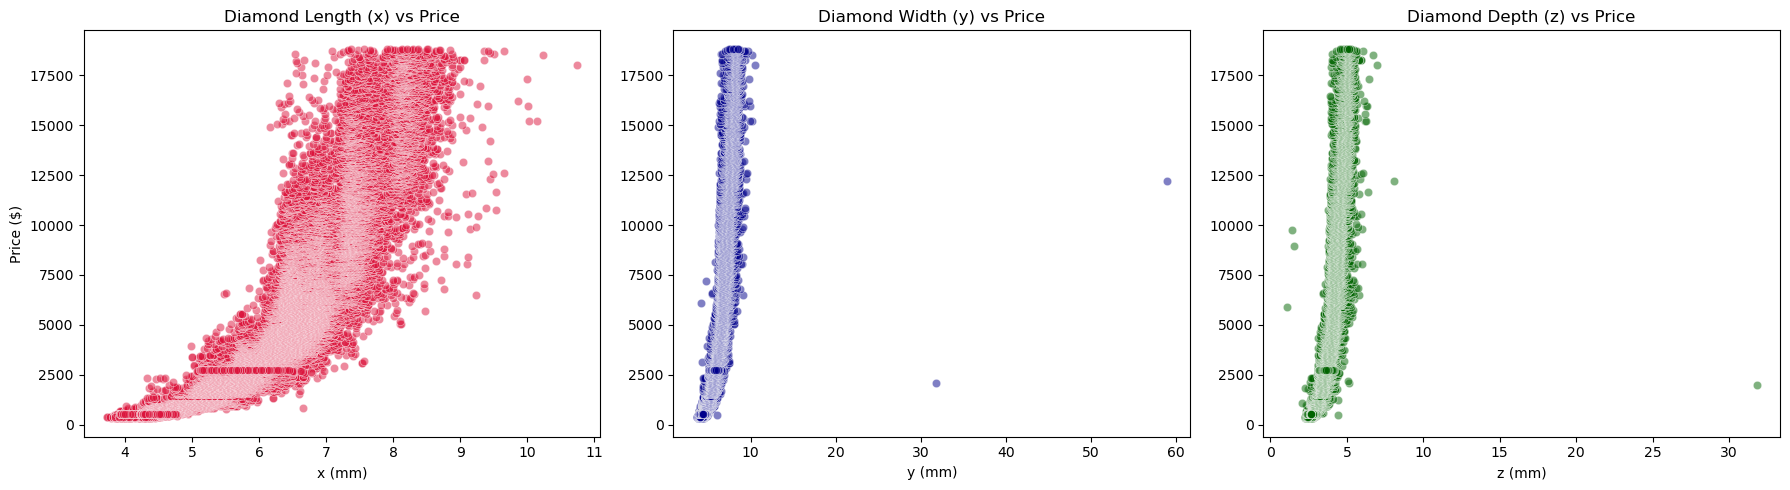

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# x vs price 
sns.scatterplot(data=df, x="x", y="price", ax=axes[0], alpha=0.5, color="crimson")
axes[0].set_title("Diamond Length (x) vs Price")
axes[0].set_xlabel("x (mm)")
axes[0].set_ylabel("Price ($)")

# y vs price 
sns.scatterplot(data=df, x="y", y="price", ax=axes[1], alpha=0.5, color="darkblue")
axes[1].set_title("Diamond Width (y) vs Price")
axes[1].set_xlabel("y (mm)")
axes[1].set_ylabel("")

# z vs price
sns.scatterplot(data=df, x="z", y="price", ax=axes[2], alpha=0.5, color="darkgreen")
axes[2].set_title("Diamond Depth (z) vs Price")
axes[2].set_xlabel("z (mm)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

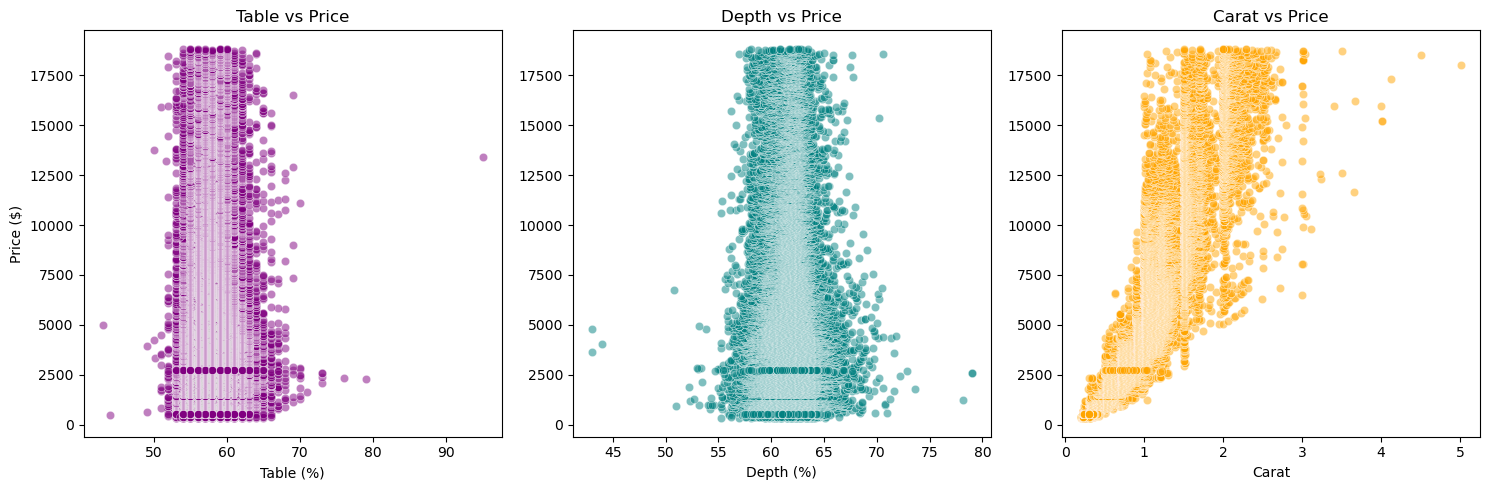

In [24]:
# table vs price
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x="table", y="price", alpha=0.5, color="purple")
plt.title("Table vs Price")
plt.xlabel("Table (%)")
plt.ylabel("Price ($)")

# depth vs price
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x="depth", y="price", alpha=0.5, color="teal")
plt.title("Depth vs Price")
plt.xlabel("Depth (%)")
plt.ylabel("")

# carat vs price
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x="carat", y="price", alpha=0.5, color="orange")
plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [25]:
len(df[df["y"] < 20]), len(df[(df["z"] > 2) & (df["z"] < 30)]), len(df[(df["table"] > 40) & (df["table"] < 75)]), len(df[(df["depth"] > 45) & (df["depth"] < 75)])

(53918, 53916, 53917, 53914)

In [26]:
df = df[df["y"] < 20]
df = df[(df["z"] > 2) & (df["z"] < 30)]
df = df[(df["table"] > 40) & (df["table"] < 75)]
df = df[(df["depth"] > 45) & (df["depth"] < 75)]

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
carat,53905.0,0.797628,0.473774,0.20,0.40,0.70,1.04,5.01
depth,53905.0,61.749545,1.419739,50.80,61.00,61.80,62.50,73.60
table,53905.0,57.455205,2.222825,43.00,56.00,57.00,59.00,73.00
price,53905.0,3930.643799,3987.264881,326.00,949.00,2401.00,5322.00,18823.00
x,53905.0,5.731476,1.119402,3.73,4.71,5.70,6.54,10.74
y,53905.0,5.733313,1.111267,3.68,4.72,5.71,6.54,10.54
z,53905.0,3.539443,0.691446,2.06,2.91,3.53,4.04,6.98


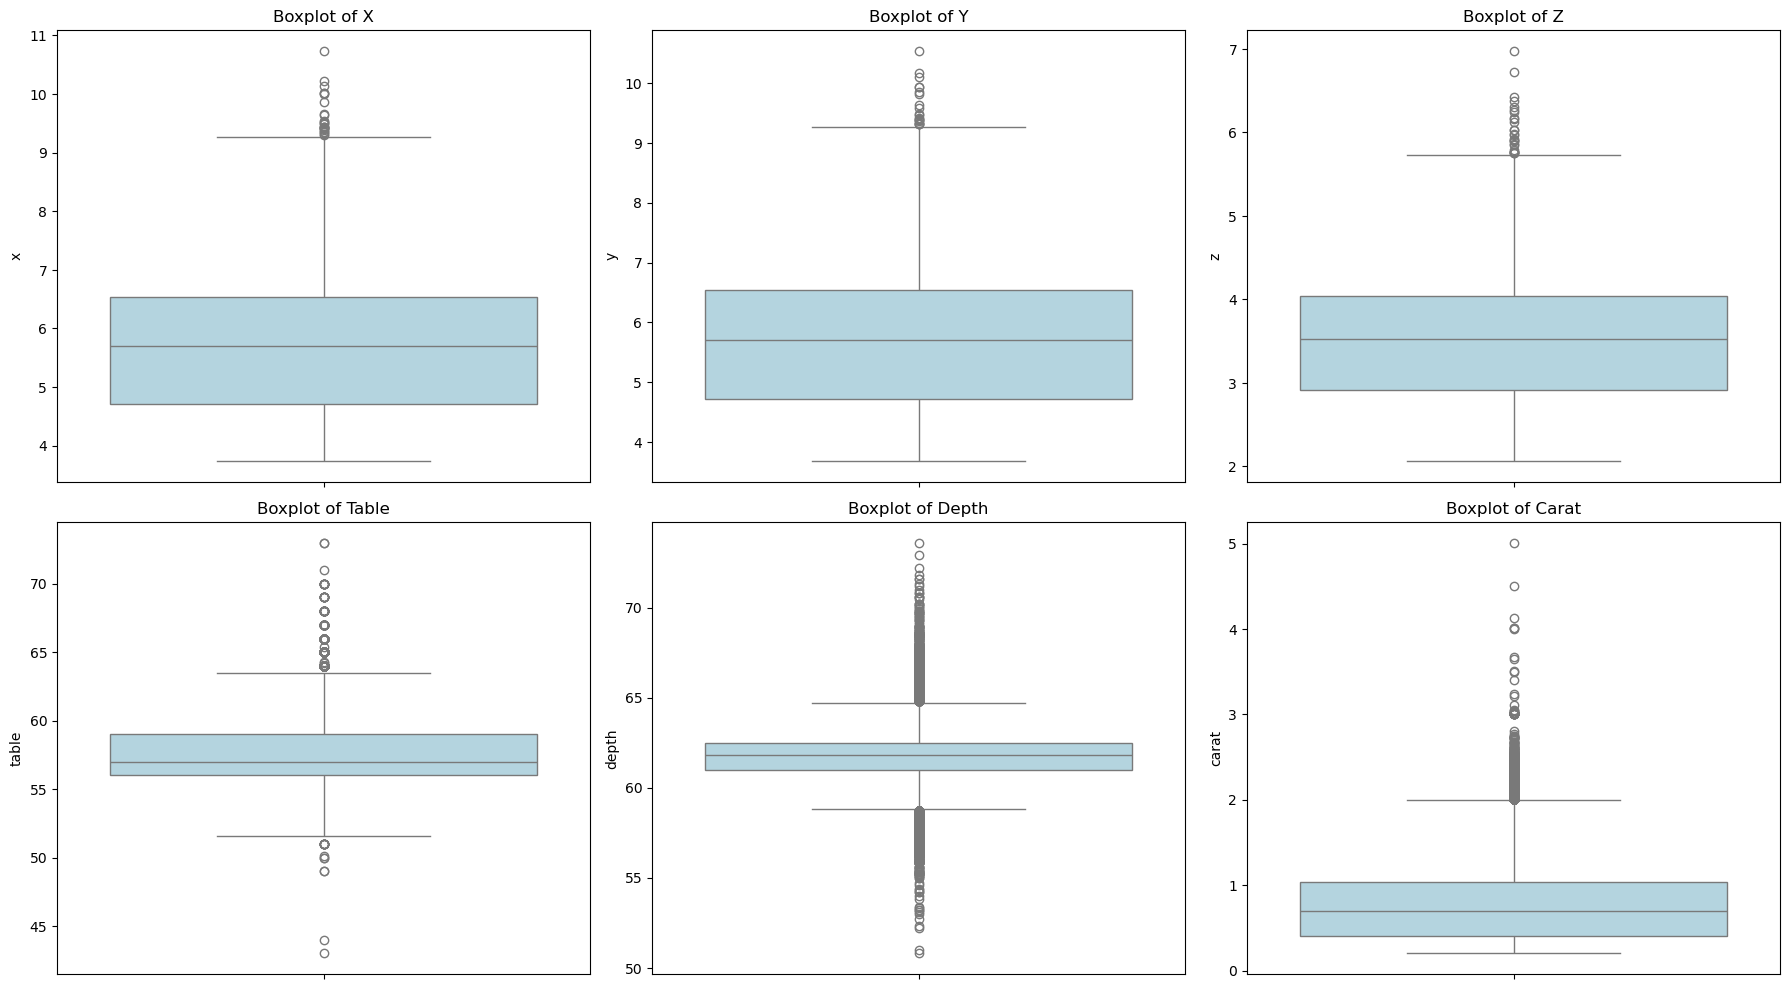

In [41]:
features = ["x", "y", "z", "table", "depth", "carat"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, y=col, ax=axes[i], color="lightblue")
    axes[i].set_title(f"Boxplot of {col.capitalize()}")
    axes[i].set_ylabel(col)
    
plt.tight_layout()
plt.show()

In [42]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53905 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53905 non-null  float64
 1   cut      53905 non-null  object 
 2   color    53905 non-null  object 
 3   clarity  53905 non-null  object 
 4   depth    53905 non-null  float64
 5   table    53905 non-null  float64
 6   price    53905 non-null  int64  
 7   x        53905 non-null  float64
 8   y        53905 non-null  float64
 9   z        53905 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.5+ MB


In [44]:
df.to_csv("../data/diamonds_cleaned.csv", index=False)

In [45]:
print("The cleaned dataset was saved as 'diamonds_cleaned.csv'.")

The cleaned dataset was saved as 'diamonds_cleaned.csv'.
